# finding the change in atmospheric temperature over the Salish Sea in CMIP6 Projection

In [12]:
import xarray as xr
import numpy as np
from cartopy import crs, feature
import matplotlib.pyplot as plt
import cmocean as cm

In [2]:
data = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/tas_Global_yearly_ensemble_ssp585_r1i1p1f1_anomaly_2081-2100_enspctl50.nc')
data

<xarray.Dataset> Size: 264kB
Dimensions:    (time: 1, bnds: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 8B 2090-12-30T18:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    tas        (time, lat, lon) float32 259kB ...
Attributes: (12/51)
    CDI:                    Climate Data Interface version ?? (http://mpimet....
    source:                 AWI-CM 1.1 MR (2018): \naerosol: none\natmos: ECH...
    institution:            Alfred Wegener Institute, Helmholtz Centre for Po...
    Conventions:            CF-1.5
    activity_id:            ScenarioMIP
    branch_method:          standard
    ...                     ...
    tracking_id:            hdl:21.14100/dfdcc564-4517-4b55-b327-2c5234b340a3
    variable_id:            tas
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.3 (http://mpim...
    history:                Tue Nov 16 06:08:55 2021: ncatted -a units,tas,m,...
    NCO:                    4.7.2

In [47]:
# need to go from 0-360 lon range to -180 to 180
lons = np.mod(data.lon.values - 180.0, 360.0) - 180.0

In [43]:
# range in temperature change
print(f"{np.min(data.tas[0,:,:].values)} to {np.max(data.tas[0,:,:].values)} C")

1.1743805408477783 to 11.424176216125488 C


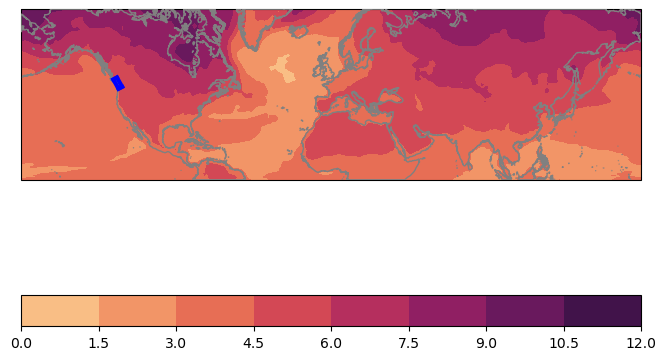

In [60]:
ylim = [0,70]
xlim = [-180,180]
fig, ax = plt.subplots(1,1, figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})

# Make plot area
ax.set_extent(xlim + ylim)

# Draw coastline
ax.add_feature(feature.GSHHSFeature('low', edgecolor='grey', zorder=4))

vmin, vmax = 1,12
X, Y = np.meshgrid(data.lon.values,data.lat.values)
cs = ax.contourf(X,Y,data.tas[0,:,:].values,vmin=-vmin,vmax=vmax,cmap=cm.cm.matter,transform=crs.PlateCarree())
fig.colorbar(cs, ax=ax, location='bottom')

# Draw SalishSeaCast box
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
ax.plot(mesh['nav_lon'][:,0], mesh['nav_lat'][:,0], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][:,-1], mesh['nav_lat'][:,-1], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][0,:], mesh['nav_lat'][0,:], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][-1,:], mesh['nav_lat'][-1,:], color='b', lw=3, zorder=6, transform=crs.PlateCarree())

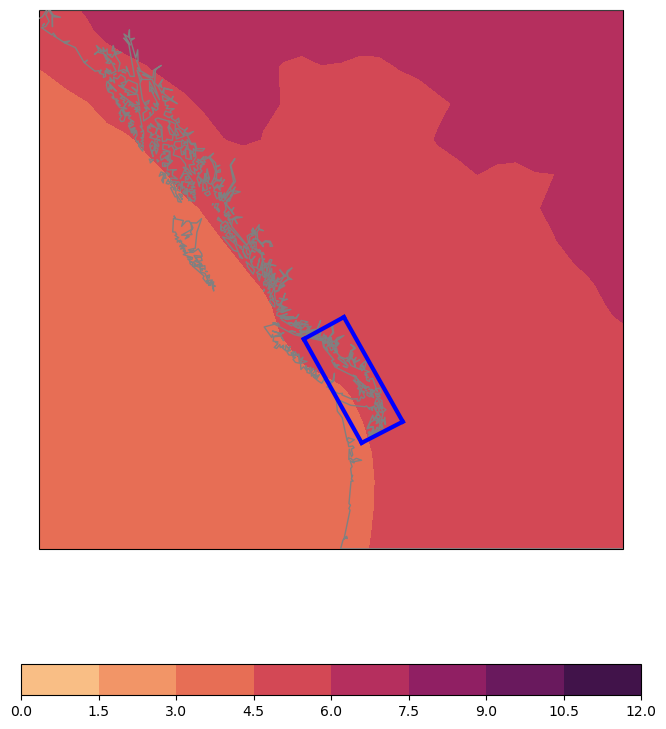

In [61]:
ylim = [43,60]
xlim = [-140,-110]
fig, ax = plt.subplots(1,1, figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})

# Make plot area
ax.set_extent(xlim + ylim)

# Draw coastline
ax.add_feature(feature.GSHHSFeature('low', edgecolor='grey', zorder=4))

vmin, vmax = 1,12
X, Y = np.meshgrid(data.lon.values,data.lat.values)
cs = ax.contourf(X,Y,data.tas[0,:,:].values,vmin=-vmin,vmax=vmax,cmap=cm.cm.matter,transform=crs.PlateCarree())
fig.colorbar(cs, ax=ax, location='bottom')

# Draw SalishSeaCast box
ax.plot(mesh['nav_lon'][:,0], mesh['nav_lat'][:,0], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][:,-1], mesh['nav_lat'][:,-1], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][0,:], mesh['nav_lat'][0,:], color='b', lw=3, zorder=6, transform=crs.PlateCarree())
ax.plot(mesh['nav_lon'][-1,:], mesh['nav_lat'][-1,:], color='b', lw=3, zorder=6, transform=crs.PlateCarree())

In [ ]:

fig, ax = plt.subplots(1,1, figsize=(8, 10)})

vmin, vmax = 1,12
X, Y = np.meshgrid(data.lon.values,data.lat.values)
ax.contourf(X,Y,data.tas[0,:,:].values,vmin=-vmin,vmax=vmax,cmap=cm.cm.matter,transform=crs.PlateCarree())


In [55]:
# lats
print(f"{np.min(mesh['nav_lat'][:,0].values)} to {np.max(mesh['nav_lat'][:,-1].values)}")

# lons
print(f"{np.min(mesh['nav_lon'][:,0].values)%360} to {np.max(mesh['nav_lon'][:,-1].values)%360}")

46.85966491699219 to 51.104801177978516
233.59970092773438 to 238.681640625


In [56]:
np.mean(data.tas[0,90+46:90+51+1,233:238+1])

<xarray.DataArray 'tas' ()> Size: 8B
array(4.77391243)
Coordinates:
    time     datetime64[ns] 8B 2090-12-30T18:00:00
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    cell_methods:   area: time: mean
    units:          C